# Clasificación K-Nearest Neighbors (KNN)
## Dataset: Potabilidad del Agua

**KNN** clasifica una observación asignándole la clase mayoritaria entre sus
`k` vecinos más cercanos. Al depender de distancias, es **obligatorio** escalar
las variables (la clase lo hace automáticamente).

### Flujo de trabajo
```
pd.read_csv(...)                # 1. Cargar datos con pandas
  ↓ limpieza y codificación     # 2. Preprocesar
mf.KNN(df, target)             # 3. Crear instancia
knn.preparar_datos()            # 4. Split + escalado
knn.ajustar()                   # 5. Entrenar el modelo
knn.plot_*()                    # 6. Visualizar resultados
knn.indices_general()           # 7. Evaluar métricas
```

## 1. Importacion de librerias

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import pckEDA as mf

%matplotlib inline
print('Clase KNN disponible:', mf.KNN)

Clase KNN disponible: <class 'pckEDA.supervisado.knn.KNN'>


## 2. Carga de datos

Al ser un algoritmo **supervisado**, KNN recibe un DataFrame ya cargado
(no una ruta CSV). Cargamos con pandas y luego pasamos el DataFrame al constructor.

In [2]:
df = pd.read_csv('../datasets/potabilidad_V2.csv', index_col=0)

print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Columnas   : {list(df.columns)}')
df.head()

Dimensiones: 2011 filas x 10 columnas
Columnas   : ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
4,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,No
5,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,No
6,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,No
7,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,No
8,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2011 entries, 4 to 3272
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   object 
dtypes: float64(9), object(1)
memory usage: 172.8+ KB


In [4]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000
mean,7.085990,195.968072,21917.441374,7.134338,333.224672,426.526409,14.357709,66.400859,3.969729
std,1.573337,32.635085,8642.239815,1.584820,41.205172,80.712572,3.324959,16.077109,0.780346
min,0.227499,73.492234,320.942611,1.390871,129.000000,201.619737,2.200000,8.577013,1.450000
25%,6.089723,176.744938,15615.665390,6.138895,307.632511,366.680307,12.124105,55.952664,3.442915
50%,7.027297,197.191839,20933.512750,7.143907,332.232177,423.455906,14.322019,66.542198,3.968177
75%,8.052969,216.441070,27182.587067,8.109726,359.330555,482.373169,16.683049,77.291925,4.514175
max,14.000000,317.338124,56488.672413,13.127000,481.030642,753.342620,27.006707,124.000000,6.494749


## 3. Preprocesamiento

### 3.1 Valores nulos

In [5]:
# Cantidad de nulos por columna
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')

Valores nulos por columna:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Total de filas con al menos un nulo: 0


In [6]:
# Imputamos nulos con la mediana de cada columna (robusto ante outliers)
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

print(f'Nulos restantes: {df.isnull().sum().sum()}')

Nulos restantes: 0


### 3.2 Codificacion de la variable objetivo

`Potability` es categórica (`"Si"` / `"No"`). La codificamos a numérica para
que sklearn pueda trabajar con ella: **No = 0**, **Si = 1**.

In [7]:
print('Valores únicos antes:', df['Potability'].unique())

df['Potability'] = df['Potability'].map({'No': 0, 'Si': 1})

print('Valores únicos después:', df['Potability'].unique())
print(f'\nDistribución:\n{df["Potability"].value_counts()}')

Valores únicos antes: ['No' 'Si']
Valores únicos después: [0 1]

Distribución:
Potability
0    1200
1     811
Name: count, dtype: int64


### 3.3 Duplicados y verificacion final

In [8]:
duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {duplicados}')
df = df.drop_duplicates()

print(f'Dimensiones finales: {df.shape}')
df.head()

Filas duplicadas: 0
Dimensiones finales: (2011, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
4,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
5,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
6,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
7,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
8,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0


## 4. Creacion de la instancia KNN

Pasamos el DataFrame limpio y el nombre de la columna objetivo al constructor.
El modelo **no se entrena** en este paso — primero exploramos los datos.

In [9]:
knn = mf.KNN(df, target='Potability', n_neighbors=5, scaler='standard')
print(knn)

KNN(n_neighbors=5, weights='uniform', metric='euclidean', no ajustado)


## 5. Analisis exploratorio de poder predictivo

Estos graficos provienen de **ModMC.py** (Profesor Juan Murillo Morera) y permiten
evaluar visualmente qué tan bien separan las variables a las clases del target.

### 5.1 Distribucion de la variable objetivo

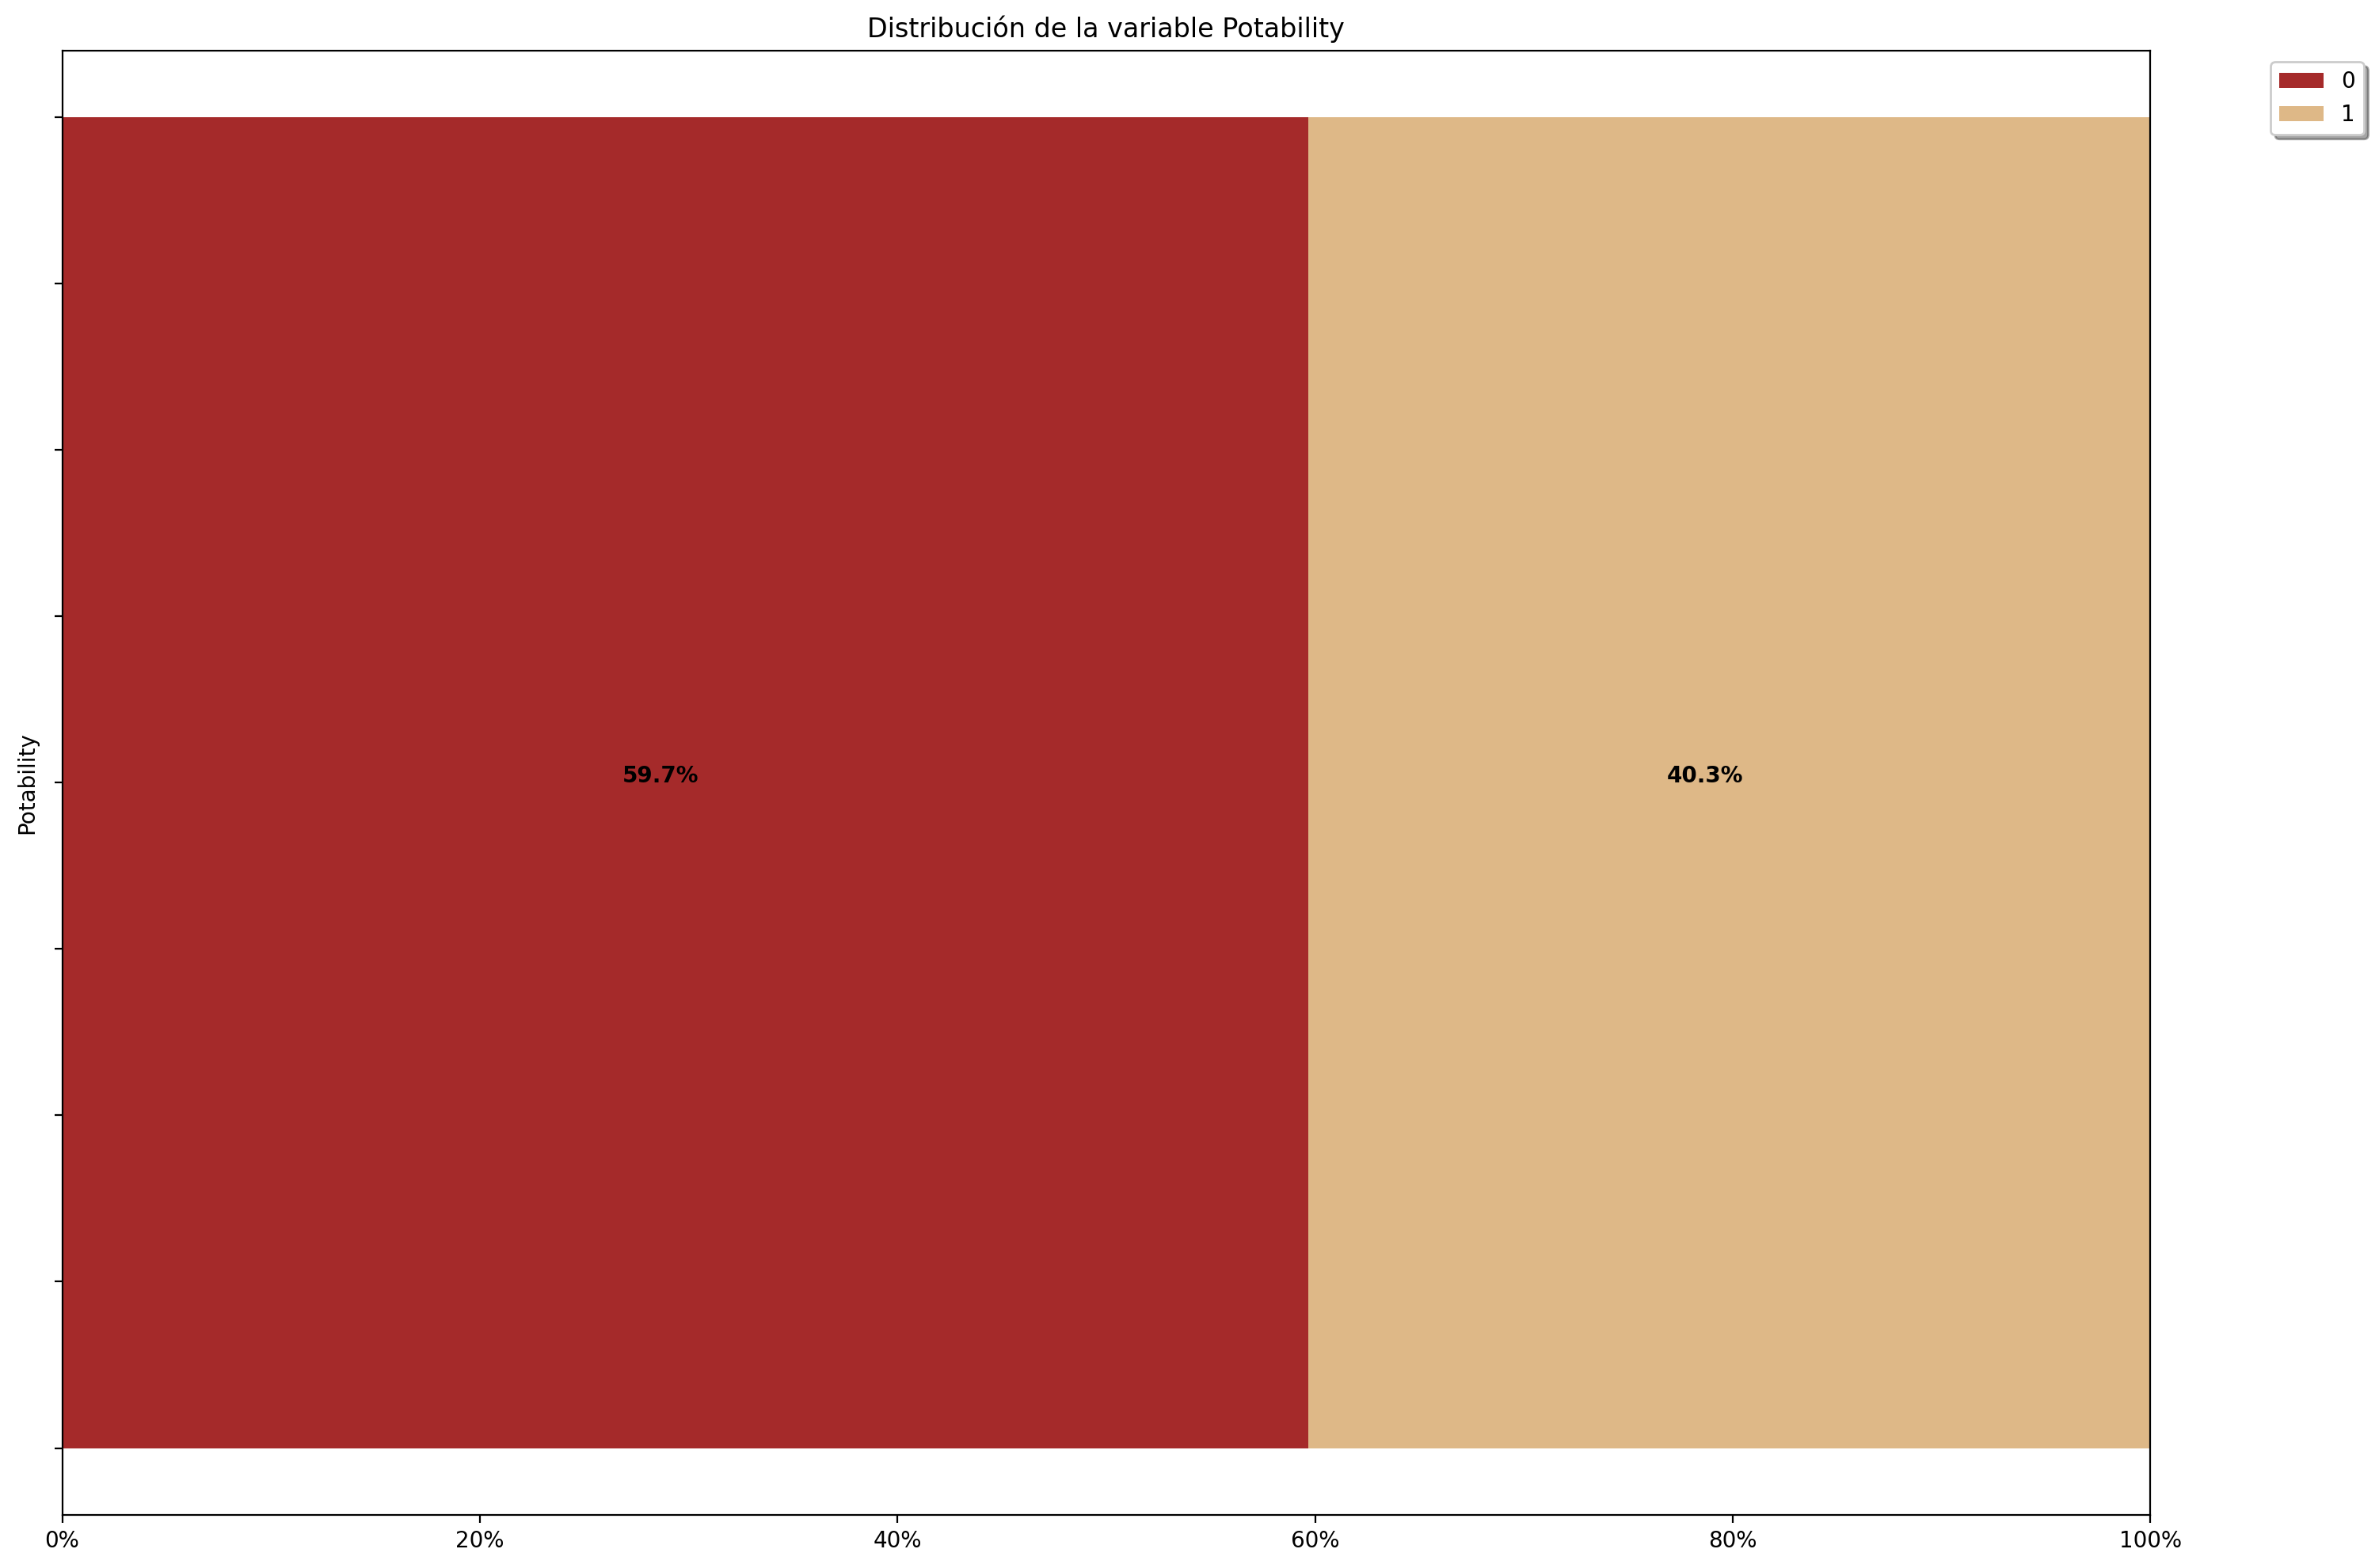

In [10]:
knn.plot_distribucion_target()
plt.tight_layout()
plt.show()

> Si una clase domina excesivamente (> 80%), las métricas de accuracy pueden ser engañosas.
> En ese caso conviene revisar precision, recall y F1-score por clase.

### 5.2 Poder predictivo de las variables numericas

Las curvas KDE muestran si la distribucion de una variable **difiere** entre clases.
A mayor separacion entre curvas, mayor poder predictivo.

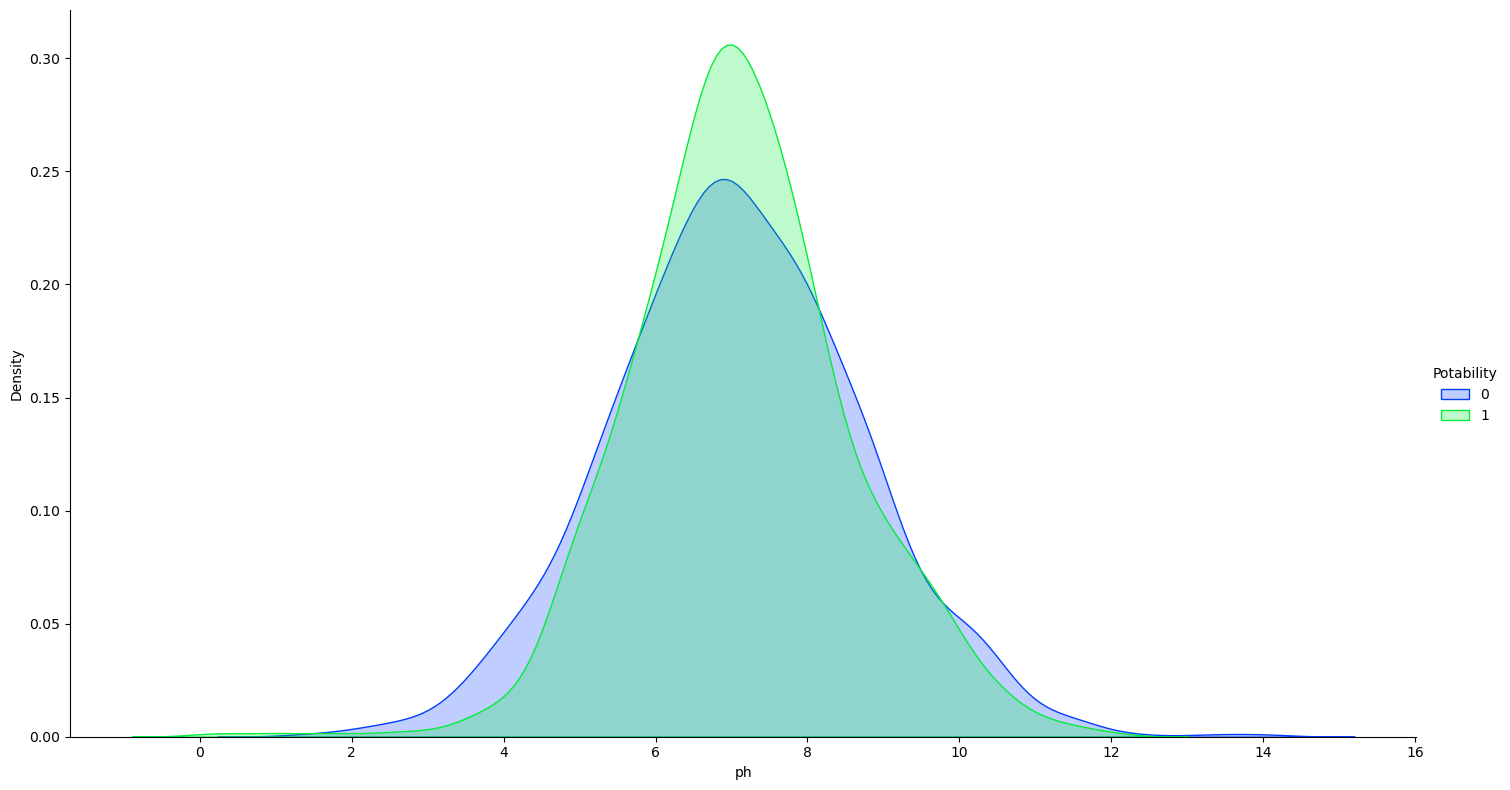

In [11]:
knn.plot_poder_predictivo_numerica('ph')
plt.show()

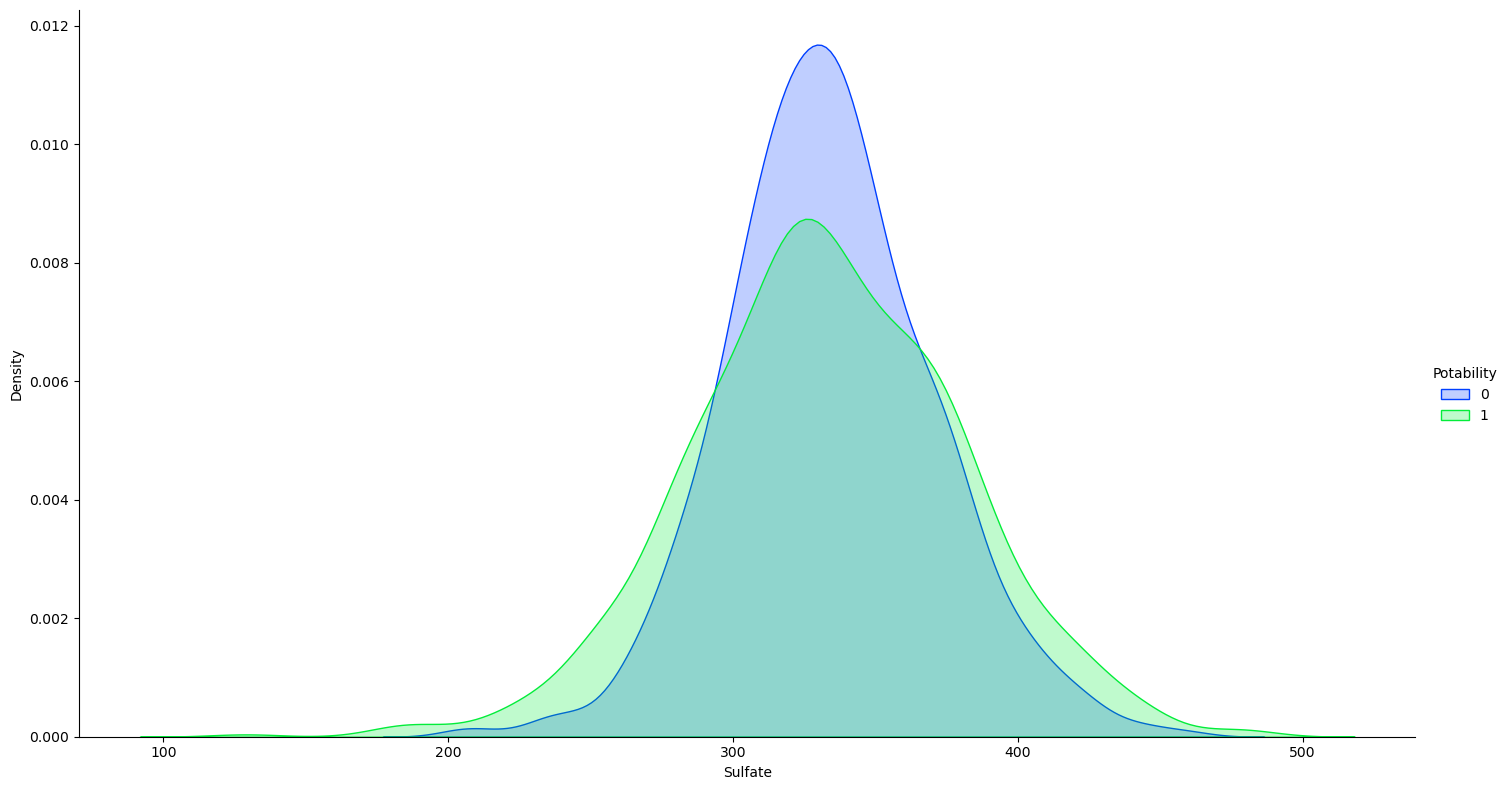

In [12]:
knn.plot_poder_predictivo_numerica('Sulfate')
plt.show()

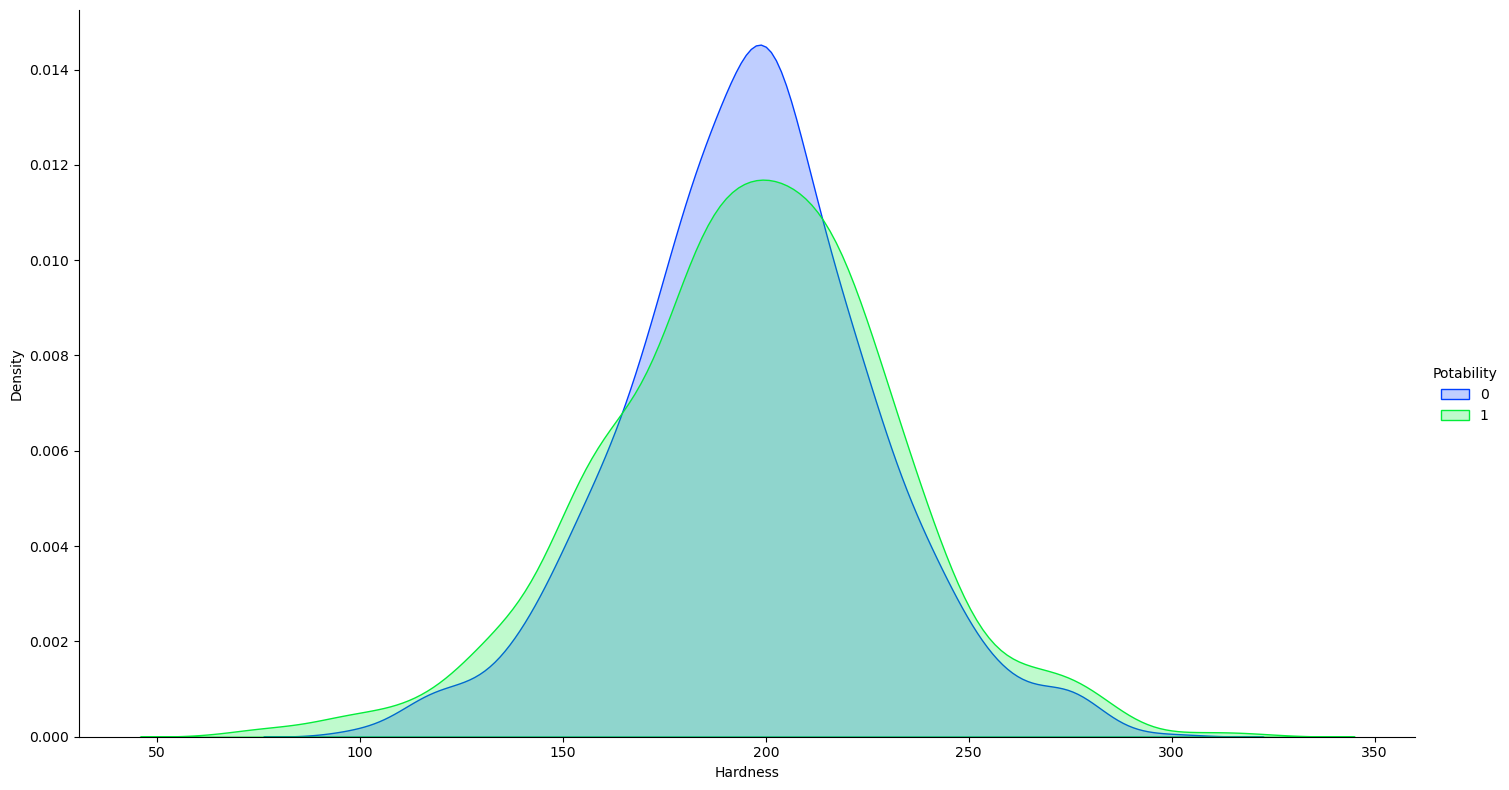

In [13]:
knn.plot_poder_predictivo_numerica('Hardness')
plt.show()

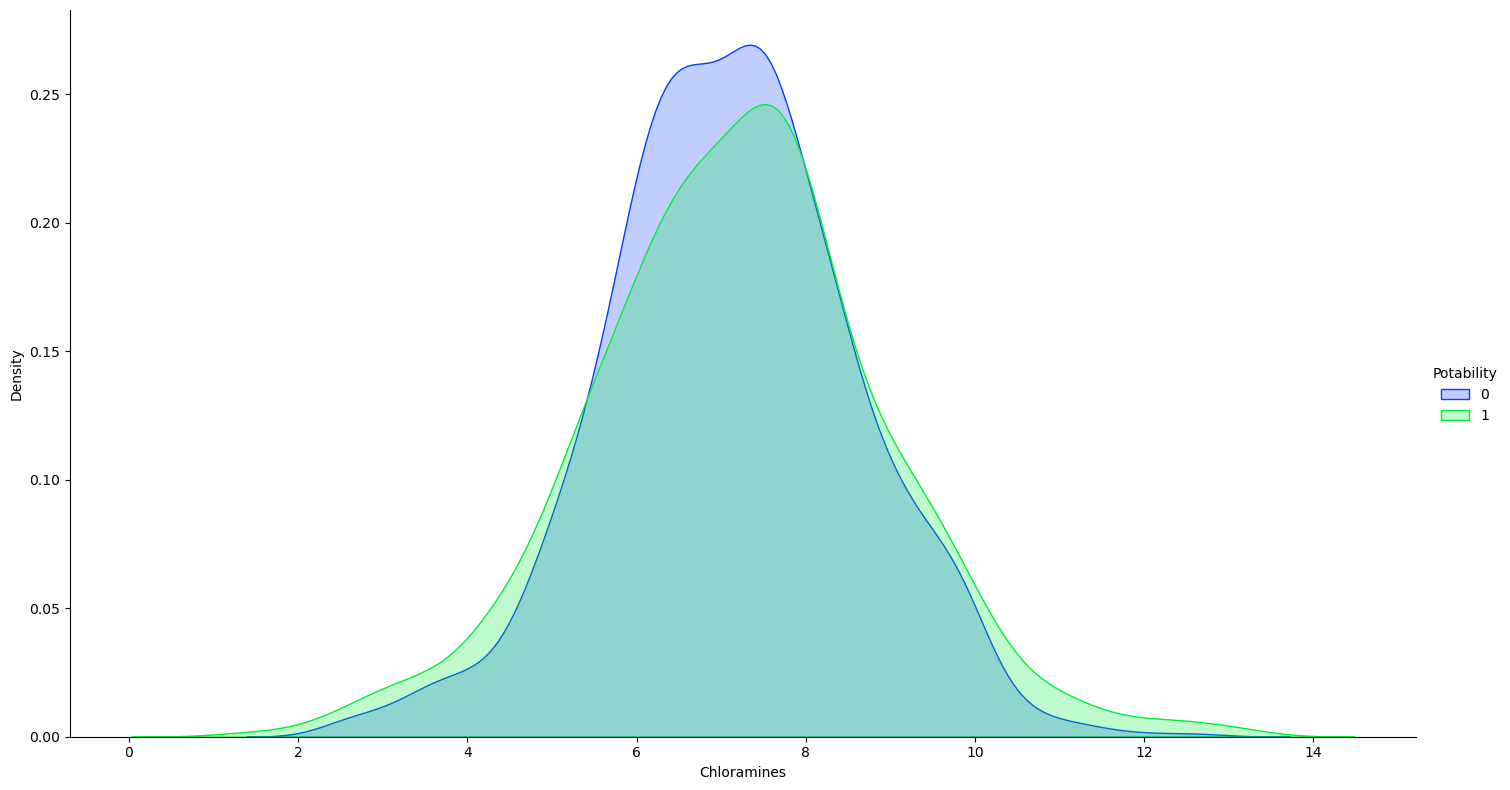

In [14]:
knn.plot_poder_predictivo_numerica('Chloramines')
plt.show()

### 5.3 Mapa de correlaciones

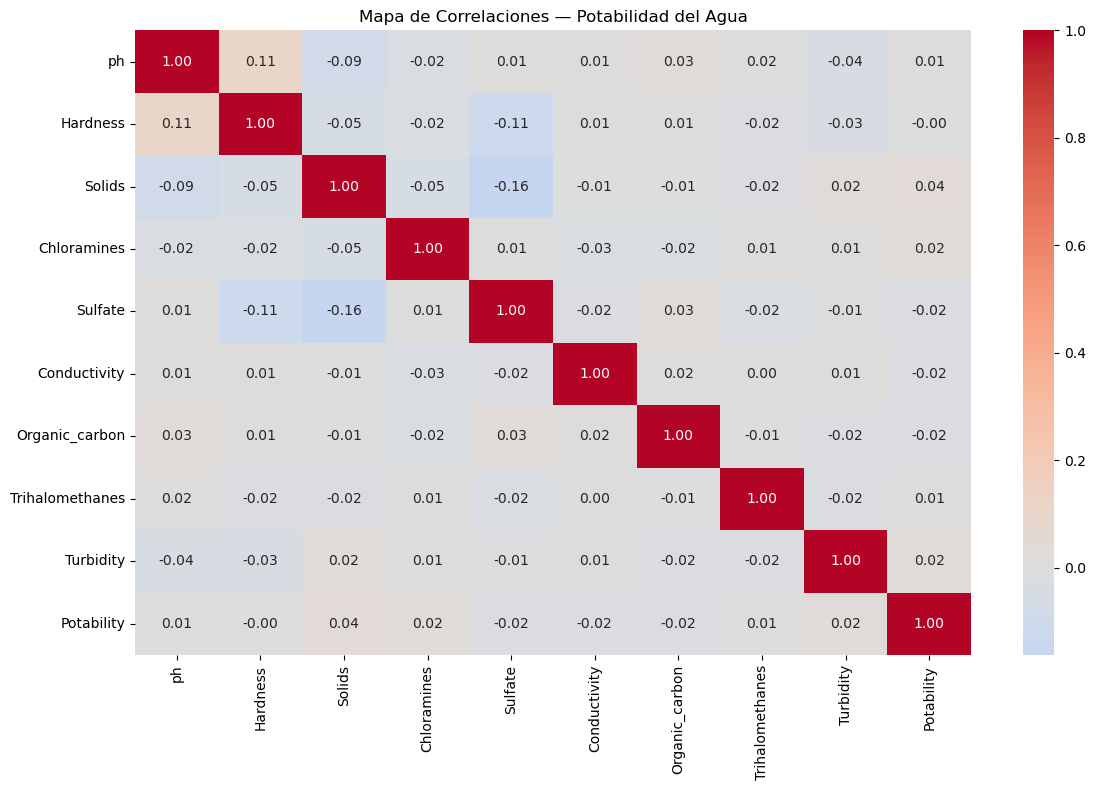

In [15]:
import seaborn as sns

plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-bright')
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de Correlaciones — Potabilidad del Agua')
plt.tight_layout()
plt.show()

## 6. Preparacion de datos y entrenamiento inicial

`preparar_datos()` separa features y target, divide en train/test con
estratificacion y escala automaticamente con StandardScaler.

In [16]:
knn.preparar_datos(test_size=0.3, random_state=42)

print(f'Train: {knn.X_train.shape[0]} filas')
print(f'Test : {knn.X_test.shape[0]} filas')
print(f'Clases: {knn.nombres_clases}')

Train: 1407 filas
Test : 604 filas
Clases: [0, 1]


In [17]:
knn.ajustar()

print(f'Exactitud (accuracy): {knn.accuracy:.4f}')
print()
print('Reporte de clasificación:')
print(knn.reporte)

Exactitud (accuracy): 0.6341

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.67      0.77      0.71       360
           1       0.56      0.44      0.49       244

    accuracy                           0.63       604
   macro avg       0.61      0.60      0.60       604
weighted avg       0.62      0.63      0.62       604



## 7. Seleccion del k optimo

### 7.1 Curva de exactitud vs. k

Evaluamos la exactitud para valores de k entre 1 y 30. El pico de la curva
sugiere el k optimo.

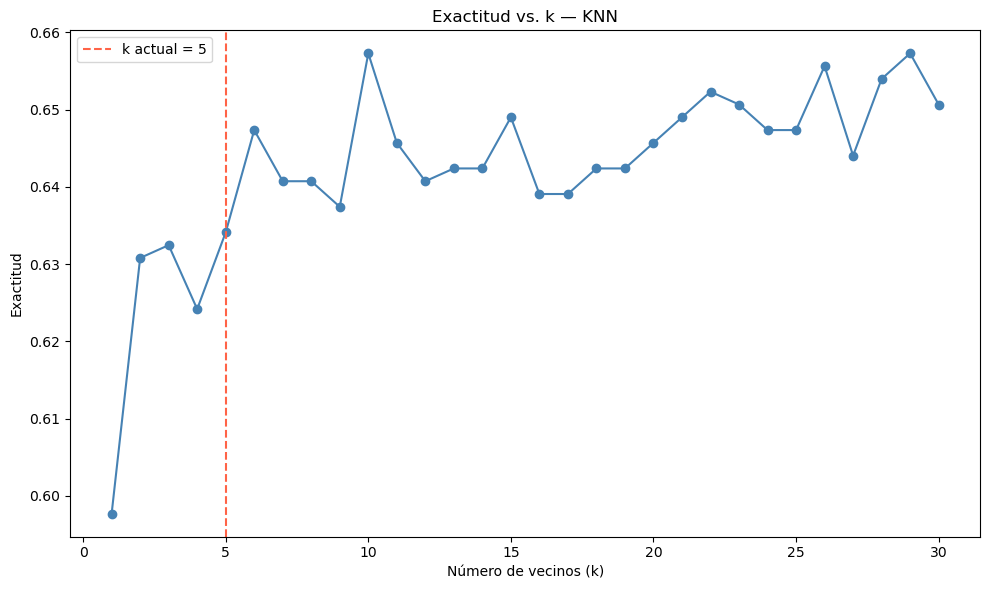

In [18]:
knn.plot_accuracy_vs_k(k_range=range(1, 31))
plt.tight_layout()
plt.show()

### 7.2 Busqueda con GridSearchCV

`buscar_mejor_k()` prueba todas las combinaciones de k y pesos (`uniform` vs.
`distance`) usando validacion cruzada de 5 folds.

In [19]:
mejores = knn.buscar_mejor_k(k_range=range(1, 31), cv=5)
print(f'Mejores hiperparámetros: {mejores}')

Mejores hiperparámetros: {'n_neighbors': 24, 'weights': 'distance'}


## 8. Re-entrenamiento con los mejores parametros

In [20]:
# Actualizamos hiperparámetros con los óptimos encontrados
knn.n_neighbors = mejores['n_neighbors']
knn.weights = mejores['weights']
knn.ajustar()

print(f'k        : {knn.n_neighbors}')
print(f'Pesos    : {knn.weights}')
print(f'Exactitud: {knn.accuracy:.4f}')
print()
print('Reporte de clasificación:')
print(knn.reporte)

k        : 24
Pesos    : distance
Exactitud: 0.6540

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75       360
           1       0.66      0.30      0.41       244

    accuracy                           0.65       604
   macro avg       0.66      0.60      0.58       604
weighted avg       0.65      0.65      0.62       604



## 9. Evaluacion del modelo

### 9.1 Matriz de confusion

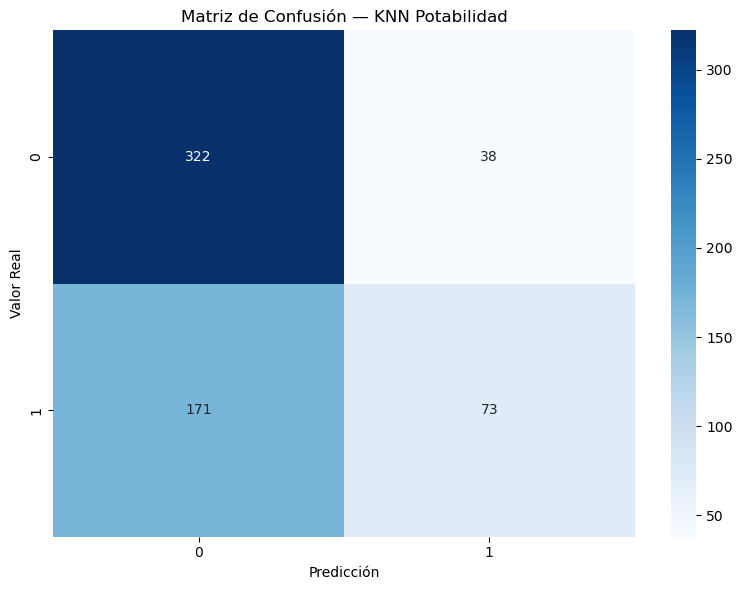

In [21]:
knn.plot_matriz_confusion(titulo='Matriz de Confusión — KNN Potabilidad')
plt.tight_layout()
plt.show()

### 9.2 Indices generales (adaptado de ModMC.py)

`indices_general()` calcula la precision global, error global y precision por
categoria a partir de la matriz de confusion.

In [22]:
indices = knn.indices_general(nombres=['No potable', 'Potable'])

print(f"Precisión Global       : {indices['Precisión Global']:.4f}")
print(f"Error Global           : {indices['Error Global']:.4f}")
print()
print('Precisión por categoría:')
indices['Precisión por categoría']

Precisión Global       : 0.6540
Error Global           : 0.3460

Precisión por categoría:


,No potable,Potable
0,0.894444,0.29918


### 9.3 Indices binarios (adaptado de ModMC.py)

Al ser un problema de 2 clases, podemos calcular metricas adicionales:
VP, VN, FP, FN, asertividad positiva/negativa, etc.

In [23]:
metricas = knn.indices_binarios()

if metricas:
    for clave, valor in metricas.items():
        print(f'{clave:50s}: {valor:.4f}')
else:
    print('indices_binarios() solo aplica para problemas de 2 clases.')

Precisión Global                                  : 0.6540
Error Global                                      : 0.3460
Precisión Positiva (PP)                           : 0.8944
Precisión Negativa (PN)                           : 0.2992
Proporción de Falsos Positivos (PFP)              : 0.3423
Proporción de Falsos Negativos (PFN)              : 0.3469
Asertividad Positiva (AP)                         : 0.6531
Asertividad Negativa (AN)                         : 0.6577


> **PP (Precisión Positiva):** De los que predije como potables, cuántos lo son realmente.  
> **AP (Asertividad Positiva / Recall):** De los que realmente son potables, cuántos detecté.  
> **PFN (Falsos Negativos):** Agua potable clasificada como no potable — puede ser costoso si descartamos agua buena.

## 10. Probabilidades de prediccion

KNN no solo predice la clase, sino que estima **probabilidades** basadas en
la proporcion de vecinos de cada clase.

In [24]:
df_prob = pd.DataFrame(
    knn.probabilidades,
    columns=['P(No potable)', 'P(Potable)'],
    index=knn.X_test.index,
)
df_prob['Predicción'] = knn.predicciones
df_prob['Real'] = knn.y_test.values
df_prob.head(10)

,P(No potable),P(Potable),Predicción,Real
1828,0.581626,0.418374,0,0
1051,0.704093,0.295907,0,0
760,0.409715,0.590285,1,1
607,0.667210,0.332790,0,0
2907,0.611374,0.388626,0,0
2886,0.743741,0.256259,0,0
1949,0.362662,0.637338,1,1
2323,0.517727,0.482273,0,1
195,0.558340,0.441660,0,0
210,0.704301,0.295699,0,0


## 11. Conclusiones

- **KNN** es un modelo sencillo e interpretable que clasifica por votacion de vecinos cercanos.
- La **curva de exactitud vs. k** y **GridSearchCV** permiten encontrar el k optimo de forma objetiva.
- Los graficos de **poder predictivo** (adaptados de ModMC.py) ayudan a identificar qué variables fisicoquimicas discriminan mejor entre agua potable y no potable.
- Los **indices binarios** (PP, PN, AP, AN, PFP, PFN) complementan el accuracy al detallar el tipo de error del modelo.
- **Limitaciones:** KNN es sensible a la dimensionalidad y al desbalance de clases. Si el rendimiento es bajo, considerar `aplicar_pca()` o técnicas de balanceo externas.